<a href="https://colab.research.google.com/github/LorenzoBioinfo/import-bioinformatics/blob/main/notebooks/QualityScanner_PDBfile_Biopython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Scanner di qualità strutturale per dataset PDB

**Chapter:** 01 — Bioinformatics Foundations  
**Level:** Beginner → Intermediate  
**Estimated time:** ~2.5 hours  


BioPython è la libreria Python standard de facto per la bioinformatica. Non è un singolo tool ma una collezione di moduli indipendenti che coprono: parsing di formati biologici (FASTA, PDB, GenBank, mmCIF), accesso a database (NCBI, PDB, UniProt), analisi di sequenze e strutture, allineamento, filogenesi e molto altro.

In questo notebook, utilizzeremo Biopython per l'analisi dei file PDB.


##  Cosa impareremo in questo notebook

-  Come scaricare automaticamente strutture proteiche dal database PDB usando `PDBList` (es. proteine come ubiquitina)
-  Come analizzare file PDB e distinguere tra informazioni **SEQRES** e **ATOM**
-  Come identificare problemi strutturali come:
    - residui mancanti
    - catene incomplete
    - valori anomali di B-factor
-  Come calcolare metriche strutturali importanti:
    - lunghezza della proteina
    - B-factor medio e massimo (sugli atomi Cα)
    - numero di catene presenti
    - numero di HETATM e molecole d’acqua
-  Come rilevare outlier strutturali basati su soglie statistiche (es. B-factor > 2× media)
-  Come costruire un dataset strutturato con `pandas` per confrontare tutte le proteine
-  Come esportare i risultati in un file CSV per analisi successive
- Come visualizzare la qualità delle strutture tramite istogrammi:
    - distribuzione delle lunghezze
    - distribuzione dei B-factor medi
    - residui mancanti per struttura
-  Come definire automaticamente una lista di strutture da scartare basandosi su criteri quantitativi (qualità strutturale)




##  Cos’è un file PDB (recap biologico)

Un file **PDB** (*Protein Data Bank*) è un formato standard utilizzato per rappresentare la struttura tridimensionale di macromolecole biologiche, come proteine e acidi nucleici.

###  Cosa contiene
Un file PDB descrive una struttura atomica completa e include informazioni come:
-  coordinate 3D di ogni atomo (x, y, z)
-  sequenza degli amminoacidi (tramite record SEQRES e ATOM)
-  legami tra atomi e residui
-  catene polipeptidiche
-  molecole associate (acqua, ligandi, ioni)
-  fattori di temperatura (**B-factor**), che indicano la mobilità degli atomi

###  A cosa serve
I file PDB permettono di:
- visualizzare la struttura 3D delle proteine
- studiare la funzione biologica a livello molecolare
- analizzare interazioni con ligandi o altre proteine
- supportare drug design e bioinformatica strutturale

###  Idea chiave
Un file PDB è, in pratica, una “fotografia atomica” di una proteina: non descrive solo la sequenza, ma la sua forma nello spazio, che è fondamentale per la funzione biologica.





## 0 - Setup

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install biopython --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.6 MB/s eta 0:00:00


## 1 Download Sequenze

Per prima cosa scarichiamo alcune sequenze e salviamole in una cartella.

Scegliamo ad esempio alcune strutture dell'ubiquitina.



In [15]:
from Bio.PDB import PDBList
import os
os.makedirs("pdb_structures",exist_ok=True)



In [16]:
PDB_IDS = [
    "1UBQ", "2ZNR", "3AUL", "1CMX", "2BGF",
    "1YIW", "3EHV", "2K39", "1F9J", "4XOL",
    "1TBE", "2XK5", "3B0B", "1AAR", "2C7M",
    "1UBI", "3NS8", "2JF5", "1WR1", "4I6J"
]

pdbl = PDBList()


for pdb_id in PDB_IDS:
    pdbl.retrieve_pdb_file(
        pdb_id,
        file_format="pdb",
        pdir="pdb_structures"
    )

print(f"Download completato. File nella cartella pdb_structures/:")
files = [f for f in os.listdir("pdb_structures") if f.endswith(".ent")]
print(f"  {len(files)} strutture scaricate")

Download completato. File nella cartella pdb_structures/:
  20 strutture scaricate


Notiamo qualcosa di strano? I file hanno estensione .ent e non .pdb. Come mai?

Il formato .ent è semplicemente il formato nativo del Protein Data Bank. Quando scarichiamo direttamente dai server FTP del RCSB, i file arrivano come pdb1ubq.ent.gz. Biopython li decomprime e li salva mantenendo l'estensione .ent.
Il contenuto è identico a un .pdb, con lo stesso formato testo, stesse righe ATOM/HETATM/SEQRES. È solo il nome che cambia.


Anche se non cambia nulla, rinominiamo i file sostituendo .ent con .pdb

In [17]:
for f in os.listdir("pdb_structures"):
    if f.endswith(".ent"):
        old = os.path.join("pdb_structures", f)
        new = os.path.join("pdb_structures", f.replace(".ent", ".pdb"))
        os.rename(old, new)

## 2 Leggiamo un file PDB

Passiamo ora alla parte del parsing del file PDB. La funzione chiave di Biopython per leggere il formato PDB è PDBparser.

Per il progetto dovremo leggere tutte le strutture ma iniziamo con la prima.

In [18]:
from Bio.PDB import PDBParser
import warnings
warnings.filterwarnings("ignore")
parser = PDBParser(QUIET=True)

structure = parser.get_structure("1UBQ", "pdb_structures/pdb1ubq.pdb")

Biopython oranizza la struttura in modo gerarchico:

Structure → Model → Chain → Residue → Atom

In [20]:
# Prendiamo il primo modello
model = structure[0]
print(model)

<Model id=0>


In [21]:
print("Catene trovate:", [chain.id for chain in model])

Catene trovate: ['A']


In [22]:
for chain in model:
    residues = [r for r in chain if r.id[0] == " "]
    print(f"  Catena {chain.id}: {len(residues)} residui")

  Catena A: 76 residui


## B-factor sui Cα

Cosa sono i B-factor?
Quando si risolve una struttura proteica a raggi X, non si ottiene una posizione fissa per ogni atomo ma si ottiene una distribuzione di probabilità di dove si trova quell'atomo nel cristallo. Il B-factor (anche chiamato temperature factor o displacement parameter) misura quanto quella distribuzione è larga, cioè quanto l'atomo si muove o è disordinato.

In pratica:

- B-factor basso (< 20 Ų) → atomo ben definito, poco mobile, alta confidenza sulla posizione
- B-factor alto (> 60 Ų) → atomo molto mobile o disordinato, posizione incerta


Nei file PDB lo trovi nella colonna 61-66 di ogni riga ATOM.

Per il QC strutturale ci interessano i Cα perché sono rappresentativi di ogni residuo. Se il Cα ha B-factor alto, tutta quella regione della proteina è problematica.


Il metodo .get_bfactor applicato all'atomo ci restituisce il valore del b factor.

In [25]:
ca_bfactors = []

for residue in model["A"]:
    if residue.id[0] == " ":          # solo residui standard, no acqua/HETATM
        if "CA" in residue:           # controlla che l'atomo Cα esista
            ca_bfactors.append(residue["CA"].get_bfactor())

print(f"Residui con Cα: {len(ca_bfactors)}")
print(f"B-factor medio:  {sum(ca_bfactors)/len(ca_bfactors):.2f}")
print(f"B-factor minimo: {min(ca_bfactors):.2f}")
print(f"B-factor massimo:{max(ca_bfactors):.2f}")

print(f"Numero di B-factor sopra >60:{len([high for high in ca_bfactors if high>60])}")

Residui con Cα: 76
B-factor medio:  10.58
B-factor minimo: 3.51
B-factor massimo:36.19
Numero di B-factor sopra >60:0


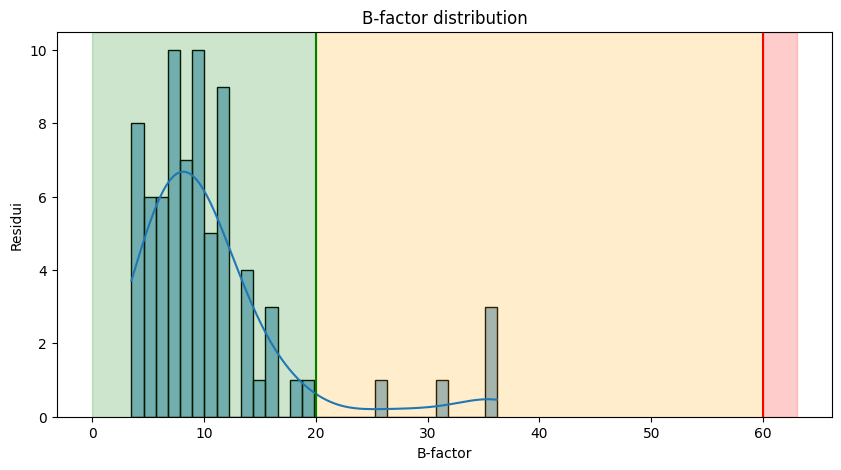

In [41]:
# Visualizziamo la distribuzione
import seaborn as sns
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(10,5))

sns.histplot(ca_bfactors, bins=30, kde=True)
plt.axvline(x=20,color="green")
plt.axvline(x=60,color="red")
ax.axvspan(0, 20, color='green', alpha=0.2)
ax.axvspan(20, 60, color='orange', alpha=0.2)
ax.axvspan(60, ax.get_xlim()[1], color='red', alpha=0.2)
plt.title("B-factor distribution")
plt.xlabel("B-factor")
plt.ylabel("Residui")
plt.show()

### Identifichiamo i residui mancanti

Prima di procedere, soffermiamoci a capire quali informazioni contiente il file PDB sulla sequenza.

Il file PDB contiene infatti due tipi di informazione sulla sequenza:

- SEQRES — la sequenza completa della proteina come è in natura (quello che dovrebbe esserci)

- ATOM — solo i residui per cui è stato possibile determinare le coordinate 3D (quello che c'è davvero nel file)


Dal confronto tra SEQRES e ATOM possiamo capire quanti residui mancanti ci sono.

In [42]:
from Bio.PDB import PDBParser
from Bio.PDB.PDBIO import PDBIO
from Bio import SeqIO

# Residui ATOM. I residui che ci sono davvero nel file
atom_residues = [
    r for r in model["A"]
    if r.id[0] == " "
]

n_atom = len(atom_residues)


print(f"Trovati {n_atom}")
print(f"Esempio dei primi 10 : {atom_residues[:10]}")


Trovati 76
Esempio dei primi 10 : [<Residue MET het=  resseq=1 icode= >, <Residue GLN het=  resseq=2 icode= >, <Residue ILE het=  resseq=3 icode= >, <Residue PHE het=  resseq=4 icode= >, <Residue VAL het=  resseq=5 icode= >, <Residue LYS het=  resseq=6 icode= >, <Residue THR het=  resseq=7 icode= >, <Residue LEU het=  resseq=8 icode= >, <Residue THR het=  resseq=9 icode= >, <Residue GLY het=  resseq=10 icode= >]


In [43]:
# Residui SEQRES — sequenza completa dichiarata nell'header
seqres_records = list(SeqIO.parse("pdb_structures/pdb1ubq.pdb", "pdb-seqres"))

# Dobbiamo ovviamente confrontare con lo stesso modello
print(seqres_records[0].id)
print(seqres_records[0].seq)


1UBQ:A
MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG


In [44]:
n_seqres = 0
for rec in seqres_records:
    if rec.annotations["chain"] == "A":
        n_seqres = len(rec.seq)
        print(f"SEQRES catena A: {rec.seq}")
        break

print(f"\nSEQRES length : {n_seqres}")
print(f"ATOM length   : {n_atom}")
print(f"Residui mancanti: {n_seqres - n_atom}")
print(f"Percentuale mancanti: {(n_seqres - n_atom) / n_seqres * 100:.1f}%")

SEQRES catena A: MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG

SEQRES length : 76
ATOM length   : 76
Residui mancanti: 0
Percentuale mancanti: 0.0%


Perfetto, in questo caso la sequenza coincide e non abbiamo residui mancanti. Vedremo come si comporteranno le altre strutture che abbiamo scaricato.

## HETATM e molecole d'acqua

Il file PDB non contiene solo la sequenza proteica ma anche tutto il resto : acqua, ligandi, ioni, cofattori ecc.

I record si dividono quindi in:

-**ATOM** :atomi della proteina (residui standard)
**HETATM** :tutto il resto

Per il QC ci interessano perché un numero altissimo di HETATM può indicare strutture co-cristallizzate con ligandi complessi, mentre le acque sono utili come indicatore di qualità della risoluzione.  Più acque modellate = struttura più accurata

In [45]:
hetatm_residues = []
water_residues = []

for chain in model:
    for residue in chain:
        if residue.id[0] == "W":        # W = acqua in Biopython
            water_residues.append(residue)
        elif residue.id[0] != " ":      # tutto il resto non-standard = HETATM
            hetatm_residues.append(residue)

print(f"HETATM (ligandi/ioni): {len(hetatm_residues)}")
print(f"Molecole d'acqua:      {len(water_residues)}")


if hetatm_residues:
    nomi = set(r.resname for r in hetatm_residues)
    print(f"Molecole HETATM trovate: {nomi}")

HETATM (ligandi/ioni): 0
Molecole d'acqua:      58


La struttura 1UBQ è molto semplice, non abbiamo ligandi ma solo 58 molecole d'acqua.

## Applichiamo il loop a tutte le strutture PDB

L'obiettivo è ora applicare le funzioni che abbiamo visto a tutte le strutture PDB scaricate.
L'output desiderato è un file csv con tutte le informazioni per ogni struttura in modo che sia semplice filtrarle .

In [47]:
import pandas as pd
parser = PDBParser(QUIET=True)
pdb_dir = "pdb_structures"
rows = []

for filename in sorted(os.listdir(pdb_dir)):
    if not filename.endswith(".pdb"):
        continue

    pdb_id = filename.replace(".pdb", "").upper()
    filepath = os.path.join(pdb_dir, filename)

    try:
        structure = parser.get_structure(pdb_id, filepath)
        # Analizziamo sempre il primo modello
        model = structure[0]

        # Numero di catene
        n_chains = len(list(model.get_chains()))

        # Residui ATOM
        atom_residues = [
            r for chain in model
            for r in chain
            if r.id[0] == " "
        ]
        n_atom = len(atom_residues)

        # Residui SEQRES
        seqres_records = list(SeqIO.parse(filepath, "pdb-seqres"))
        seqres_by_chain = {
            rec.annotations["chain"]: len(rec.seq)
            for rec in seqres_records
        }

        missing = 0
        for chain in model:
            chain_id = chain.id
            n_atom_chain = sum(1 for r in chain if r.id[0] == " ")
            n_seqres_chain = seqres_by_chain.get(chain_id, n_atom_chain)
            missing += max(0, n_seqres_chain - n_atom_chain)

        n_seqres = sum(seqres_by_chain.values()) if seqres_by_chain else n_atom
        missing_pct = round(missing / n_seqres * 100, 1) if n_seqres > 0 else 0

        #  B-factor sui Cα
        ca_bfactors = [
            r["CA"].get_bfactor()
            for chain in model
            for r in chain
            if r.id[0] == " " and "CA" in r
        ]
        bf_mean = round(sum(ca_bfactors) / len(ca_bfactors), 2) if ca_bfactors else None
        bf_max  = round(max(ca_bfactors), 2) if ca_bfactors else None


        # Outlier B-factor (> 2× media)
        if ca_bfactors and bf_mean:
            n_outliers = sum(1 for b in ca_bfactors if b > 2 * bf_mean)
        else:
            n_outliers = 0

        #  HETATM e acque
        n_hetatm = sum(
            1 for chain in model
            for r in chain
            if r.id[0] not in (" ", "W")
        )
        n_water = sum(
            1 for chain in model
            for r in chain
            if r.id[0] == "W"
        )

        rows.append({
            "pdb_id"        : pdb_id,
            "n_chains"      : n_chains,
            "seqres_length" : n_seqres,
            "atom_length"   : n_atom,
            "missing_res"   : missing,
            "missing_pct"   : missing_pct,
            "bf_mean"       : bf_mean,
            "bf_max"        : bf_max,
            "bf_outliers"   : n_outliers,
            "n_hetatm"      : n_hetatm,
            "n_water"       : n_water,
        })

    except Exception as e:
        print(f"  ⚠ Errore su {pdb_id}: {e}")

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv("pdb_qc_report.csv", index=False)



 pdb_id  n_chains  seqres_length  atom_length  missing_res  missing_pct  bf_mean  bf_max  bf_outliers  n_hetatm  n_water
PDB1AAR         2            152          152            0          0.0    13.12   33.85            6         0       15
PDB1CMX         4            622          515          107         17.2    53.14  100.00            0         2       75
PDB1F9J         2            152          149            3          2.0    37.74   78.87            1         0        0
PDB1TBE         2            152          148            4          2.6    13.90   24.04            0         0        0
PDB1UBI         1             76           76            0          0.0    10.97   40.00            9         0       81
PDB1UBQ         1             76           76            0          0.0    10.58   36.19            5         0       58
PDB1WR1         2            134          134            0          0.0     0.00    0.00            0         0        0
PDB1YIW         3            228

### Visualizzazioni

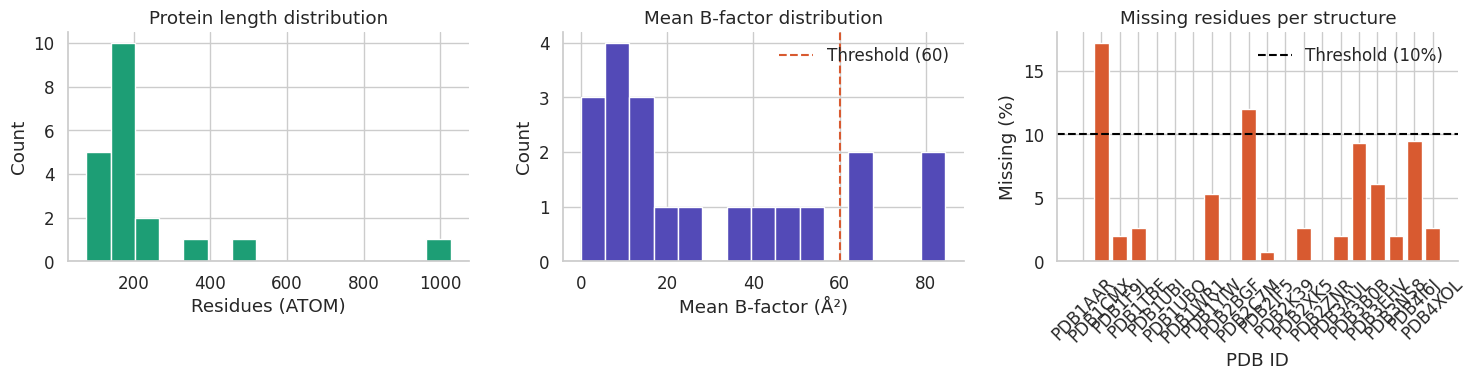

In [48]:
## Visualizzazione

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].hist(df["atom_length"], bins=15, color="#1D9E75", edgecolor="white")
axes[0].set_title("Protein length distribution")
axes[0].set_xlabel("Residues (ATOM)")
axes[0].set_ylabel("Count")


axes[1].hist(df["bf_mean"].dropna(), bins=15, color="#534AB7", edgecolor="white")
axes[1].axvline(60, color="#D85A30", linestyle="--", linewidth=1.5, label="Threshold (60)")
axes[1].set_title("Mean B-factor distribution")
axes[1].set_xlabel("Mean B-factor (Å²)")
axes[1].set_ylabel("Count")
axes[1].legend(frameon=False)

axes[2].bar(df["pdb_id"], df["missing_pct"], color="#D85A30", edgecolor="white")
axes[2].axhline(10, color="black", linestyle="--", linewidth=1.5, label="Threshold (10%)")
axes[2].set_title("Missing residues per structure")
axes[2].set_xlabel("PDB ID")
axes[2].set_ylabel("Missing (%)")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig("pdb_qc_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## Filtro finale

Utilizziamo ora il dataframe per filtrare le strutture.

In [49]:
# Rimuoviamo le strutture con una percentuale di missing >10 e un
# valore di bf_mean maggiore di 60
THRESHOLD_MISSING_PCT = 10.0
THRESHOLD_BF_MEAN     = 60.0

discard = df[
    (df["missing_pct"] > THRESHOLD_MISSING_PCT) |
    (df["bf_mean"]     > THRESHOLD_BF_MEAN)
].copy()

discard["reason"] = ""
discard.loc[df["missing_pct"] > THRESHOLD_MISSING_PCT, "reason"] += "missing_residues "
discard.loc[df["bf_mean"]     > THRESHOLD_BF_MEAN,     "reason"] += "high_bfactor"
discard["reason"] = discard["reason"].str.strip()

print(f"Strutture da scartare: {len(discard)} / {len(df)}")
print()
print(discard[["pdb_id", "missing_pct", "bf_mean", "reason"]].to_string(index=False))


discard.to_csv("pdb_discard_list.csv", index=False)
print("\nSalvato: pdb_discard_list.csv")


keep = df[~df["pdb_id"].isin(discard["pdb_id"])]
print(f"\nStrutture da tenere: {len(keep)} / {len(df)}")
print(keep["pdb_id"].tolist())

Strutture da scartare: 5 / 20

 pdb_id  missing_pct  bf_mean                        reason
PDB1CMX         17.2    53.14              missing_residues
PDB2C7M         12.0    65.15 missing_residues high_bfactor
PDB2XK5          2.6    84.37                  high_bfactor
PDB3B0B          9.3    64.79                  high_bfactor
PDB4XOL          2.6    84.54                  high_bfactor

Salvato: pdb_discard_list.csv

Strutture da tenere: 15 / 20
['PDB1AAR', 'PDB1F9J', 'PDB1TBE', 'PDB1UBI', 'PDB1UBQ', 'PDB1WR1', 'PDB1YIW', 'PDB2BGF', 'PDB2JF5', 'PDB2K39', 'PDB2ZNR', 'PDB3AUL', 'PDB3EHV', 'PDB3NS8', 'PDB4I6J']


## Recap delle funzioni e dei concetti chiave

| Funzione / Classe            | Modulo        | Cosa fa |
|-----------------------------|--------------|--------|
| `PDBList()`                 | Bio.PDB      | Interfaccia per scaricare strutture dal RCSB PDB |
| `pdbl.retrieve_pdb_file()`  | Bio.PDB      | Scarica un singolo file PDB dato l'accession ID |
| `PDBParser(QUIET=True)`     | Bio.PDB      | Parser per leggere file PDB senza stampare warning |
| `parser.get_structure()`    | Bio.PDB      | Carica una struttura PDB in memoria come oggetto gerarchico |
| `structure[0]`              | Bio.PDB      | Accede al primo modello (utile per strutture NMR multi-modello) |
| `model.get_chains()`        | Bio.PDB      | Itera sulle catene del modello |
| `residue.id[0]`             | Bio.PDB      | Identifica il tipo di residuo: " " standard, "W" acqua, altro = HETATM |
| `residue["CA"]`             | Bio.PDB      | Accede all'atomo Cα di un residuo |
| `atom.get_bfactor()`        | Bio.PDB      | Restituisce il B-factor di un atomo |
| `structure.header`          | Bio.PDB      | Dizionario con metadati dell'header PDB (risoluzione, metodo, etc.) |
| `SeqIO.parse(file, "pdb-seqres")` | Bio.SeqIO | Legge le righe SEQRES dal file PDB come record di sequenza |
| `rec.annotations["chain"]`  | Bio.SeqIO    | Recupera l'ID della catena da un record SEQRES |






| Concetto            | Significato |
|--------------------|-------------|
| B-factor           | Misura la mobilità/disordine di un atomo nella struttura cristallografica |
| SEQRES             | Sequenza completa dichiarata nell'header del PDB |
| ATOM               | Solo i residui con coordinate 3D effettivamente determinate |
| HETATM             | Ligandi, ioni, cofattori — tutto ciò che non è proteina standard |
| Residui mancanti   | Differenza SEQRES − ATOM per catena |
| Outlier B-factor   | Residui con B-factor > 2× la media — regioni problematiche |
| Gerarchia PDB      | Structure → Model → Chain → Residue → Atom |

##

## Esercizi

### Esercizio 1
Attualmente abbiamo usato 2 soli criteri per filtrare le strutture: la percentuale di missing e il b factor medio.
Prova ad aggiungere un altro criterio : filtra via le strutture in cui i B-factor outliers (residues with B-factor > 2× mean) sono il 15% dei residui

<details>
<summary>Show solution</summary>

``` python
THRESHOLD_OUTLIER_PCT = 15.0

df["bf_outlier_pct"] = round(df["bf_outliers"] / df["atom_length"] * 100, 1)

discard = df[
    (df["missing_pct"]    > THRESHOLD_MISSING_PCT) |
    (df["bf_mean"]        > THRESHOLD_BF_MEAN)     |
    (df["bf_outlier_pct"] > THRESHOLD_OUTLIER_PCT)
].copy()

discard["reason"] = ""
discard.loc[df["missing_pct"]    > THRESHOLD_MISSING_PCT, "reason"] += "missing_residues "
discard.loc[df["bf_mean"]        > THRESHOLD_BF_MEAN,     "reason"] += "high_bfactor "
discard.loc[df["bf_outlier_pct"] > THRESHOLD_OUTLIER_PCT, "reason"] += "high_bf_outliers"
discard["reason"] = discard["reason"].str.strip()


```


### Esercizio 2

Un'altra informazione che fornisce il file PDB è la risoluzione della struttura X-ray  (in Å) . Un valore inferiore è meglio. Le strutture con risoluzione sopra i 3.0 Å sono considerate di bassa qualità.

Estrai l'informazione con la funzione structure.header["resolution"], aggiungi questa informazione come colonna del dataframe e aggiungi un nuovo filtro per scartare le strutture con risoluzione >3.0 Å.



<details>
<summary>Show solution</summary>

``` python
## nel loop
resolution = structure.header.get("resolution", None)

rows.append({
    ...
    "resolution": resolution,
})


# nei filtri

THRESHOLD_RESOLUTION = 3.0
discard = df[
    ...
    (df["resolution"] > THRESHOLD_RESOLUTION)
]
discard.loc[df["resolution"] > THRESHOLD_RESOLUTION, "reason"] += "low_resolution"

```
</details>


###  Esercizio 3 : Multi-chain structures
Alcune entry PDB contengono più catene che sono in realtà copie identiche tra loro (omo-oligomeri). Per queste strutture, il confronto SEQRES vs ATOM effettuato per catena può produrre risultati fuorvianti se una catena è completa e un’altra no.

Modifica la pipeline in modo da riportare i residui mancanti per ciascuna catena invece che come totale unico, ed evidenziare le strutture in cui almeno una singola catena presenta più del 10% di residui mancanti.
